# Phase 5: Memory & Conversation

This notebook demonstrates:
1. **MemorySaver** checkpointing for multi-turn conversations
2. **Human-in-the-loop** approval gate via `interrupt()`
3. **Selective agent re-invocation** with cascade rules

The graph now pauses after generating a plan so the user can approve or request modifications. Modifications only re-run the affected agents.

## 1. Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command

from src.state import TravelPlanState
from src.supervisor import (
    parse_intent, supervisor_router, aggregate_results,
    human_review, after_human_review,
)
from src.agents.destination_agent import destination_research_agent
from src.agents.flight_agent import flight_search_agent
from src.agents.hotel_agent import hotel_search_agent
from src.agents.activity_agent import activity_itinerary_agent
from src.agents.budget_agent import budget_currency_agent

print("All imports successful!")

All imports successful!


## 2. Build Graph with Memory

The graph now includes a `human_review` node between `aggregator` and `END`, compiled with a `MemorySaver` checkpointer.

In [3]:
# Build the graph
builder = StateGraph(TravelPlanState)

# Nodes
builder.add_node("intent_parser", parse_intent)
builder.add_node("destination_research", destination_research_agent)
builder.add_node("flight_search", flight_search_agent)
builder.add_node("hotel_search", hotel_search_agent)
builder.add_node("activity_itinerary", activity_itinerary_agent)
builder.add_node("budget_currency", budget_currency_agent)
builder.add_node("aggregator", aggregate_results)
builder.add_node("human_review", human_review)

# Edges
builder.add_edge(START, "intent_parser")
builder.add_conditional_edges("intent_parser", supervisor_router)
builder.add_conditional_edges("destination_research", supervisor_router)
builder.add_conditional_edges("flight_search", supervisor_router)
builder.add_conditional_edges("hotel_search", supervisor_router)
builder.add_conditional_edges("activity_itinerary", supervisor_router)
builder.add_conditional_edges("budget_currency", supervisor_router)
builder.add_edge("aggregator", "human_review")
builder.add_conditional_edges("human_review", after_human_review)

# Compile with checkpointer
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

print("Graph compiled with MemorySaver checkpointer!")
print(f"Nodes: {list(graph.get_graph().nodes.keys())}")

Graph compiled with MemorySaver checkpointer!
Nodes: ['__start__', 'intent_parser', 'destination_research', 'flight_search', 'hotel_search', 'activity_itinerary', 'budget_currency', 'aggregator', 'human_review', '__end__']


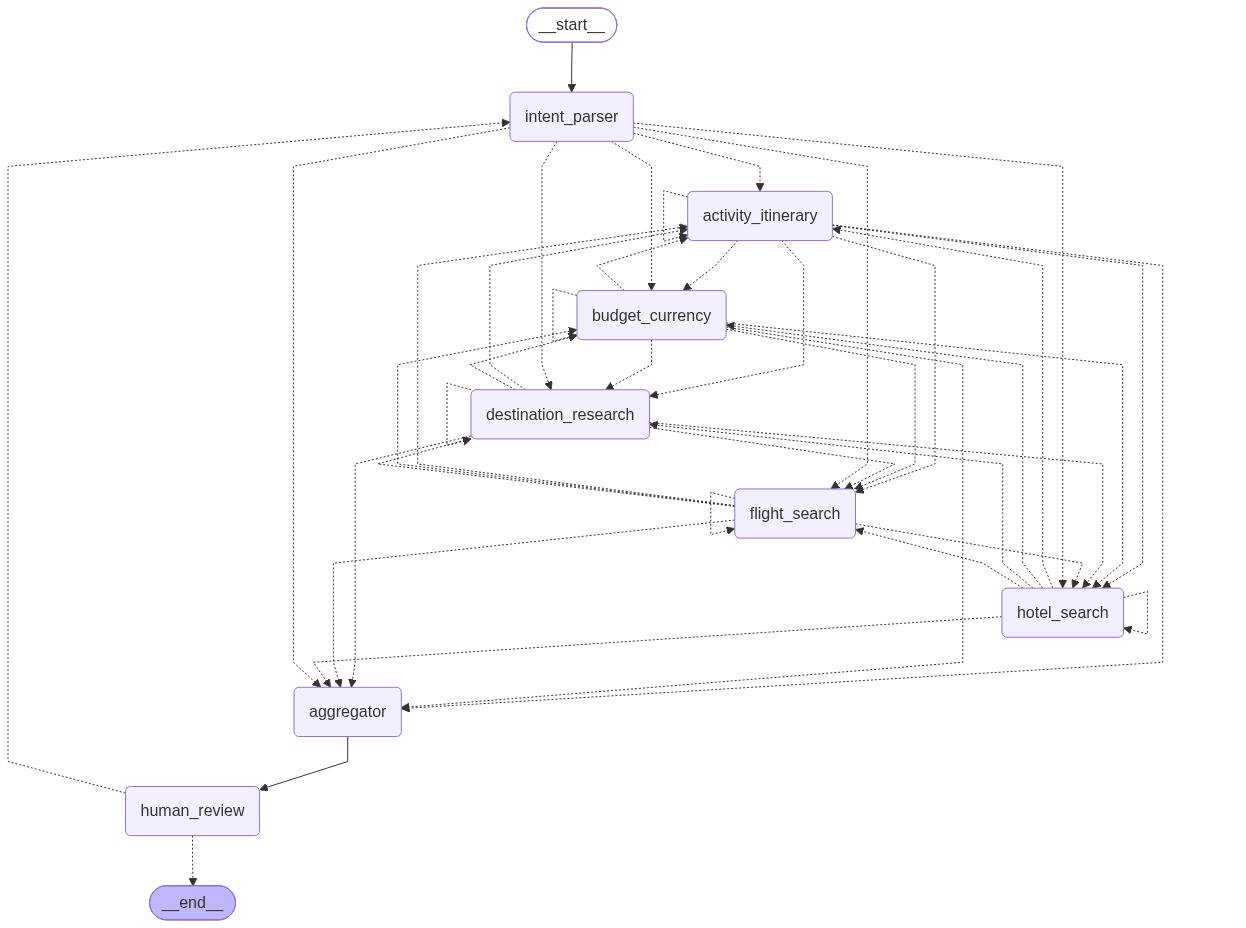

In [4]:
# Visualize the graph — note the human_review node and its loop back to intent_parser
from IPython.display import Image, display

try:
    img = graph.get_graph().draw_mermaid_png()
    display(Image(img))
except Exception as e:
    print(f"Visualization requires internet (Mermaid API): {e}")
    print("Graph structure:")
    print("  START -> intent_parser -> [agents via supervisor_router] -> aggregator -> human_review")
    print("  human_review -> END (approved) or -> intent_parser (revising)")

## 3. Turn 1: Initial Request

Start a new conversation with a Maldives trip request. The graph runs all 5 agents, generates a plan, and pauses at `human_review` for approval.

In [ ]:
# Thread config — all turns in this conversation share the same thread_id
config = {"configurable": {"thread_id": "travel-session-1"}}

# Helper to safely print (handles emoji from Claude)
def safe(s):
    return s.encode('ascii', 'replace').decode('ascii') if isinstance(s, str) else str(s)

# Turn 1: Initial request
print("=" * 70)
print("  TURN 1: Initial Maldives Trip Request")
print("=" * 70)
print()

result = graph.invoke(
    {"messages": [HumanMessage(content=(
        "Plan a 7-day luxury beach vacation in the Maldives for 2 people, "
        "budget $5000, departing from New York. "
        "Dates: 2025-06-10 to 2025-06-17. "
        "Preferences: beach, snorkeling, spa."
    ))]},
    config,
)

In [ ]:
# The graph paused at human_review (interrupt). Let's see what the interrupt returned.
state = graph.get_state(config)

print(f"Plan status: {state.values.get('plan_status')}")
print(f"Next node(s): {state.next}")
print()

# Show the interrupt payload (the plan)
if state.tasks:
    for task in state.tasks:
        if hasattr(task, 'interrupts') and task.interrupts:
            for intr in task.interrupts:
                plan_data = intr.value
                print("--- INTERRUPT: Plan for Review ---")
                print(safe(plan_data.get('plan', 'No plan'))[:2000])
                print("...")
                print()
                print(f"Prompt: {plan_data.get('prompt', '')}")

In [ ]:
# Inspect Turn 1 state
s = state.values
print("Turn 1 - Agent outputs populated:")
print(f"  destination_research: {'YES' if s.get('destination_research') else 'NO'}")
print(f"  flight_options: {'YES' if s.get('flight_options') else 'NO'} ({len(s.get('flight_options', {}).get('options', []))} options)")
print(f"  hotel_options: {'YES' if s.get('hotel_options') else 'NO'} ({len(s.get('hotel_options', {}).get('options', []))} options)")
print(f"  itinerary: {'YES' if s.get('itinerary') else 'NO'} ({len(s.get('itinerary', {}).get('days', []))} days)")
print(f"  budget_summary: {'YES' if s.get('budget_summary') else 'NO'}")
print(f"  iteration_count: {s.get('iteration_count')}")
print(f"  travel_request destination: {s.get('travel_request', {}).get('destination')}")

## 4. Turn 2: "Find cheaper hotels"

This modification should only re-run **Hotel + Budget** agents. Destination, flights, and itinerary stay the same.

In [ ]:
print("=" * 70)
print("  TURN 2: Find cheaper hotels")
print("=" * 70)
print()

# Resume with a modification request
result2 = graph.invoke(
    Command(resume="Find cheaper hotels, lower the budget to $3500"),
    config,
)

In [ ]:
# Check what happened — which agents ran?
state2 = graph.get_state(config)
s2 = state2.values

print(f"Plan status: {s2.get('plan_status')}")
print(f"Iteration: {s2.get('iteration_count')}")
print(f"Budget changed to: ${s2.get('travel_request', {}).get('budget_usd')}")
print(f"Invalidated agents: {s2.get('invalidated_agents', [])}")
print()

# Show which agents were invalidated (from the AI message)
for msg in s2.get('messages', []):
    if hasattr(msg, 'content') and 'Re-running' in str(msg.content):
        print(f"Agent re-run message: {safe(msg.content)}")
        break

print()
print("Interrupt payload (updated plan):")
if state2.tasks:
    for task in state2.tasks:
        if hasattr(task, 'interrupts') and task.interrupts:
            for intr in task.interrupts:
                plan_data = intr.value
                # Show just the budget section
                plan_text = plan_data.get('plan', '')
                budget_idx = plan_text.find('BUDGET SUMMARY')
                if budget_idx > 0:
                    print(safe(plan_text[budget_idx:budget_idx+500]))

## 5. Turn 3: "Change dates to April"

Date changes should cascade to **Flight + Hotel + Activity + Budget** (4 agents). Only destination research stays.

In [ ]:
print("=" * 70)
print("  TURN 3: Change dates to April")
print("=" * 70)
print()

result3 = graph.invoke(
    Command(resume="Change the dates to April 10-17, 2025-04-10 to 2025-04-17"),
    config,
)

In [ ]:
state3 = graph.get_state(config)
s3 = state3.values

print(f"Iteration: {s3.get('iteration_count')}")
print(f"Dates: {s3.get('travel_request', {}).get('start_date')} to {s3.get('travel_request', {}).get('end_date')}")
print(f"Destination (unchanged): {s3.get('travel_request', {}).get('destination')}")
print()

for msg in s3.get('messages', []):
    if hasattr(msg, 'content') and 'Re-running' in str(msg.content):
        print(f"Agent re-run message: {safe(msg.content)}")

## 6. Turn 4: "Change destination to Bali"

Destination change cascades to **all 5 agents** — everything must be re-planned.

In [ ]:
print("=" * 70)
print("  TURN 4: Change destination to Bali")
print("=" * 70)
print()

result4 = graph.invoke(
    Command(resume="Actually, change the destination to Bali instead"),
    config,
)

In [ ]:
state4 = graph.get_state(config)
s4 = state4.values

print(f"Iteration: {s4.get('iteration_count')}")
print(f"Destination: {s4.get('travel_request', {}).get('destination')}")
print(f"Budget: ${s4.get('travel_request', {}).get('budget_usd')}")
print()

for msg in s4.get('messages', []):
    if hasattr(msg, 'content') and 'Re-running' in str(msg.content):
        print(f"Agent re-run message: {safe(msg.content)}")

print()
print("Updated plan preview:")
if state4.tasks:
    for task in state4.tasks:
        if hasattr(task, 'interrupts') and task.interrupts:
            for intr in task.interrupts:
                plan_text = intr.value.get('plan', '')
                print(safe(plan_text[:1500]))
                print("...")

## 7. Turn 5: Approve the Plan

The user approves the final plan. The graph completes and reaches END.

In [ ]:
print("=" * 70)
print("  TURN 5: Approve")
print("=" * 70)
print()

result5 = graph.invoke(
    Command(resume="approve"),
    config,
)

state5 = graph.get_state(config)
s5 = state5.values

print(f"Plan status: {s5.get('plan_status')}")
print(f"Next nodes: {state5.next}")
print(f"Iteration count: {s5.get('iteration_count')}")
print()

# Final message
last_msg = s5['messages'][-1]
print(f"Final message: {safe(last_msg.content)}")

## 8. State Inspection

Examine the full conversation history and final state.

In [ ]:
# Full message history
final_state = graph.get_state(config).values

print("=" * 70)
print("  CONVERSATION HISTORY")
print("=" * 70)
print()

for i, msg in enumerate(final_state['messages']):
    role = msg.__class__.__name__
    content = safe(msg.content)[:150]
    print(f"  [{i:2d}] {role:12s}: {content}")

print()
print(f"Total messages: {len(final_state['messages'])}")

In [ ]:
# Final state summary
print("=" * 70)
print("  FINAL STATE")
print("=" * 70)
print()

req = final_state.get('travel_request', {})
print(f"  Destination:  {req.get('destination')}")
print(f"  Origin:       {req.get('origin')}")
print(f"  Dates:        {req.get('start_date')} to {req.get('end_date')}")
print(f"  Budget:       ${req.get('budget_usd')}")
print(f"  Travelers:    {req.get('travelers')}")
print(f"  Preferences:  {req.get('preferences')}")
print()
print(f"  Plan status:  {final_state.get('plan_status')}")
print(f"  Iterations:   {final_state.get('iteration_count')}")
print()

budget = final_state.get('budget_summary', {})
if budget:
    print(f"  Budget total:  ${budget.get('total_usd', 0)}")
    print(f"  Budget status: {budget.get('budget_status', 'N/A')}")

prev = final_state.get('previous_travel_request', {})
if prev:
    print(f"\n  Previous request destination: {prev.get('destination')} (before last change)")

## 9. Verification

Confirm that each turn ran the correct subset of agents.

In [ ]:
print("=" * 70)
print("  VERIFICATION")
print("=" * 70)
print()

s = final_state

# Check final state correctness
checks = [
    ("Plan status is complete", s.get('plan_status') == 'complete'),
    ("Destination changed to Bali", 'bali' in s.get('travel_request', {}).get('destination', '').lower()),
    ("Budget was reduced", s.get('travel_request', {}).get('budget_usd', 0) < 5000),
    ("Dates were changed to April", '04' in s.get('travel_request', {}).get('start_date', '')),
    ("Iteration count is 3 (3 modifications)", s.get('iteration_count') == 3),
    ("All agent outputs populated", all(
        s.get(f) is not None
        for f in ['destination_research', 'flight_options', 'hotel_options', 'itinerary', 'budget_summary']
    )),
    ("Flight options: 3 results", len(s.get('flight_options', {}).get('options', [])) == 3),
    ("Hotel options: 3 results", len(s.get('hotel_options', {}).get('options', [])) == 3),
    ("Itinerary has correct days", len(s.get('itinerary', {}).get('days', [])) == 7),
    ("Budget summary has total_usd", 'total_usd' in s.get('budget_summary', {})),
    ("Human feedback recorded", s.get('human_feedback') == 'approve'),
    ("Previous request tracked", s.get('previous_travel_request') is not None),
]

pass_count = 0
for name, result in checks:
    status = 'PASS' if result else 'FAIL'
    if result:
        pass_count += 1
    print(f"  [{status}] {name}")

print()
print(f"  {pass_count}/{len(checks)} checks passed")
print()
print("Phase 5 demonstration complete!")
print("Next: Phase 6 (LangSmith Observability)")